## Import Libraries

In [27]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# SHAP for model interpretation
import shap

# Set plot style (try different styles based on availability)
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('default')
        print("Note: Using default matplotlib style")

sns.set_palette('husl')

print("✓ Libraries imported successfully")
print(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ Libraries imported successfully
Analysis Date: 2026-02-24 01:35:00


In [33]:
# Load cleaned dataset
df = pd.read_csv('../data/phone-details/cleaned_my_dataset.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nDataset Info:")
print(f"  - Total samples: {len(df)}")
print(f"  - Features: {df.columns.tolist()}")
print(f"\nFirst few rows:")

df = df.drop(columns=['Condition','SIM Support','Network'])

df.head()

Dataset Shape: (1039, 7)

Dataset Info:
  - Total samples: 1039
  - Features: ['Price', 'Condition', 'Brand', 'RAM', 'Memory', 'SIM Support', 'Network']

First few rows:


,Price,Brand,RAM,Memory
0,35000,Samsung,6,128
1,102000,Apple,9,128
2,14000,Samsung,4,64
3,18000,Samsung,4,64
4,126000,Apple,6,256


In [34]:
# Basic statistics
print("Dataset Statistics:")
print("=" * 60)
df.describe()

Dataset Statistics:


,Price,RAM,Memory
count,1039.000000,1039.000000,1039.000000
mean,71083.725698,6.276227,158.829644
std,72512.033314,3.296481,78.034334
min,1200.000000,2.000000,32.000000
25%,22000.000000,4.000000,128.000000
50%,46500.000000,6.000000,128.000000
75%,88750.000000,8.000000,256.000000
max,442000.000000,16.000000,256.000000


## 2. Data Loading & Preprocessing

In [36]:
# Prepare features and target
X = df.drop(columns=['Price'], errors='ignore')
y = df['Price']

# One-hot encode model column
X_encoded = pd.get_dummies(X, columns=['Brand'], drop_first=True)

print(f"Feature Matrix Shape: {X_encoded.shape}")
print(f"Target Variable Shape: {y.shape}")
print(f"\nFeatures after encoding: {X_encoded.shape[1]}")
print(f"\nFeature names:")
for i, col in enumerate(X_encoded.columns, 1):
    print(f"  {i:2d}. {col}")

Feature Matrix Shape: (1039, 10)
Target Variable Shape: (1039,)

Features after encoding: 10

Feature names:
   1. RAM
   2. Memory
   3. Brand_Google
   4. Brand_Honor
   5. Brand_Huawei
   6. Brand_Oppo
   7. Brand_Other brand
   8. Brand_Samsung
   9. Brand_Vivo
  10. Brand_Xiaomi


In [37]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print("Data Split:")
print("=" * 60)
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Testing set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"\nTraining price range: Rs. {y_train.min():,.0f} - Rs. {y_train.max():,.0f}")
print(f"Testing price range:  Rs. {y_test.min():,.0f} - Rs. {y_test.max():,.0f}")

Data Split:
Training set: 831 samples (80.0%)
Testing set:  208 samples (20.0%)

Training price range: Rs. 1,200 - Rs. 442,000
Testing price range:  Rs. 2,700 - Rs. 442,000


In [38]:
# Test different number of trees
print("Testing different number of trees...")
print("=" * 60)

n_estimators_range = [10, 25, 50, 100, 150, 200]
results_trees = []

for n_trees in n_estimators_range:
    rf = RandomForestRegressor(
        n_estimators=n_trees,
        max_depth=15,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    
    train_score = rf.score(X_train, y_train)
    test_score = rf.score(X_test, y_test)
    
    results_trees.append({
        'n_estimators': n_trees,
        'train_r2': train_score,
        'test_r2': test_score,
        'gap': train_score - test_score
    })
    
    print(f"Trees: {n_trees:3d} | Train R²: {train_score:.4f} | Test R²: {test_score:.4f} | Gap: {train_score-test_score:.4f}")

results_trees_df = pd.DataFrame(results_trees)
print("\n✓ Tree count analysis complete")

Testing different number of trees...
Trees:  10 | Train R²: 0.7777 | Test R²: 0.6431 | Gap: 0.1346
Trees:  25 | Train R²: 0.7799 | Test R²: 0.6278 | Gap: 0.1521
Trees:  50 | Train R²: 0.7812 | Test R²: 0.6093 | Gap: 0.1719
Trees: 100 | Train R²: 0.7806 | Test R²: 0.6065 | Gap: 0.1741
Trees: 150 | Train R²: 0.7808 | Test R²: 0.6058 | Gap: 0.1749
Trees: 200 | Train R²: 0.7808 | Test R²: 0.6037 | Gap: 0.1771

✓ Tree count analysis complete


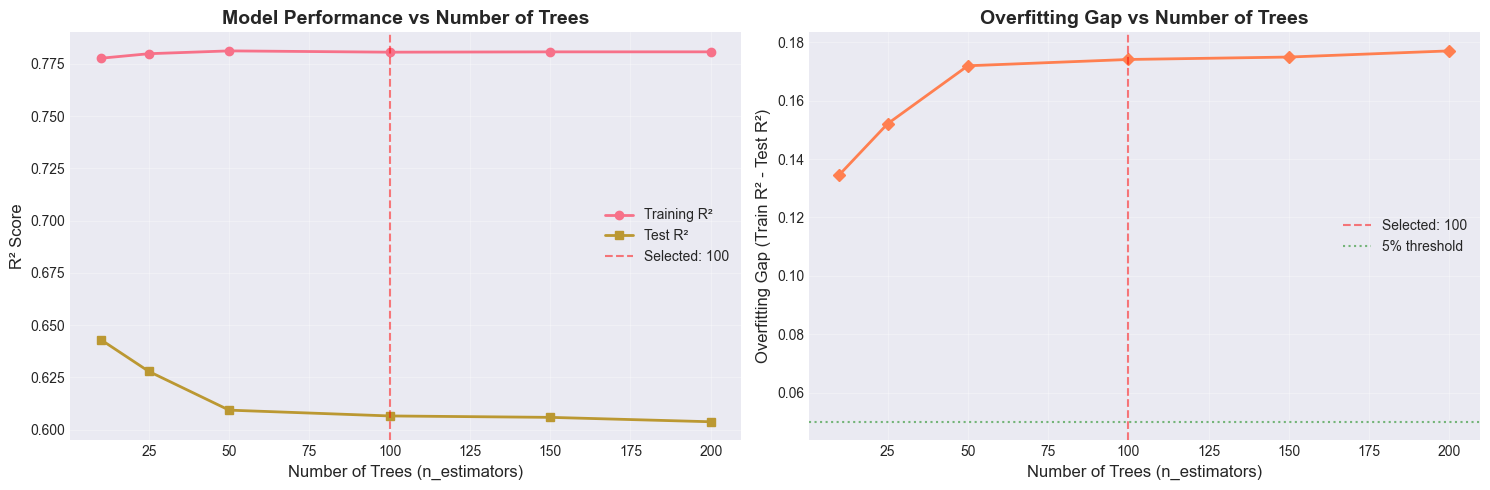


📊 Analysis: 100 trees provides good balance between performance and efficiency
   - Test R² at 100 trees: 0.6065
   - Minimal improvement beyond 100 trees


In [39]:
# Visualize n_estimators impact
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: R² scores
axes[0].plot(results_trees_df['n_estimators'], results_trees_df['train_r2'], 
             marker='o', label='Training R²', linewidth=2)
axes[0].plot(results_trees_df['n_estimators'], results_trees_df['test_r2'], 
             marker='s', label='Test R²', linewidth=2)
axes[0].axvline(x=100, color='red', linestyle='--', alpha=0.5, label='Selected: 100')
axes[0].set_xlabel('Number of Trees (n_estimators)', fontsize=12)
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('Model Performance vs Number of Trees', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Overfitting gap
axes[1].plot(results_trees_df['n_estimators'], results_trees_df['gap'], 
             marker='D', color='coral', linewidth=2)
axes[1].axvline(x=100, color='red', linestyle='--', alpha=0.5, label='Selected: 100')
axes[1].axhline(y=0.05, color='green', linestyle=':', alpha=0.5, label='5% threshold')
axes[1].set_xlabel('Number of Trees (n_estimators)', fontsize=12)
axes[1].set_ylabel('Overfitting Gap (Train R² - Test R²)', fontsize=12)
axes[1].set_title('Overfitting Gap vs Number of Trees', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Analysis: 100 trees provides good balance between performance and efficiency")
print(f"   - Test R² at 100 trees: {results_trees_df[results_trees_df['n_estimators']==100]['test_r2'].values[0]:.4f}")
print(f"   - Minimal improvement beyond 100 trees")

In [40]:
# Test different max_depth values
print("\nTesting different max_depth values...")
print("=" * 60)

max_depth_range = [5, 10, 15, 20, 25, None]
results_depth = []

for depth in max_depth_range:
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=depth,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    
    train_score = rf.score(X_train, y_train)
    test_score = rf.score(X_test, y_test)
    
    results_depth.append({
        'max_depth': str(depth),
        'train_r2': train_score,
        'test_r2': test_score,
        'gap': train_score - test_score
    })
    
    depth_str = str(depth) if depth else 'None'
    print(f"Depth: {depth_str:>4} | Train R²: {train_score:.4f} | Test R²: {test_score:.4f} | Gap: {train_score-test_score:.4f}")

results_depth_df = pd.DataFrame(results_depth)
print("\n✓ Depth analysis complete")


Testing different max_depth values...
Depth:    5 | Train R²: 0.5607 | Test R²: 0.5389 | Gap: 0.0218
Depth:   10 | Train R²: 0.7595 | Test R²: 0.6127 | Gap: 0.1468
Depth:   15 | Train R²: 0.7806 | Test R²: 0.6065 | Gap: 0.1741
Depth:   20 | Train R²: 0.7806 | Test R²: 0.6065 | Gap: 0.1741
Depth:   25 | Train R²: 0.7806 | Test R²: 0.6065 | Gap: 0.1741
Depth: None | Train R²: 0.7806 | Test R²: 0.6065 | Gap: 0.1741

✓ Depth analysis complete


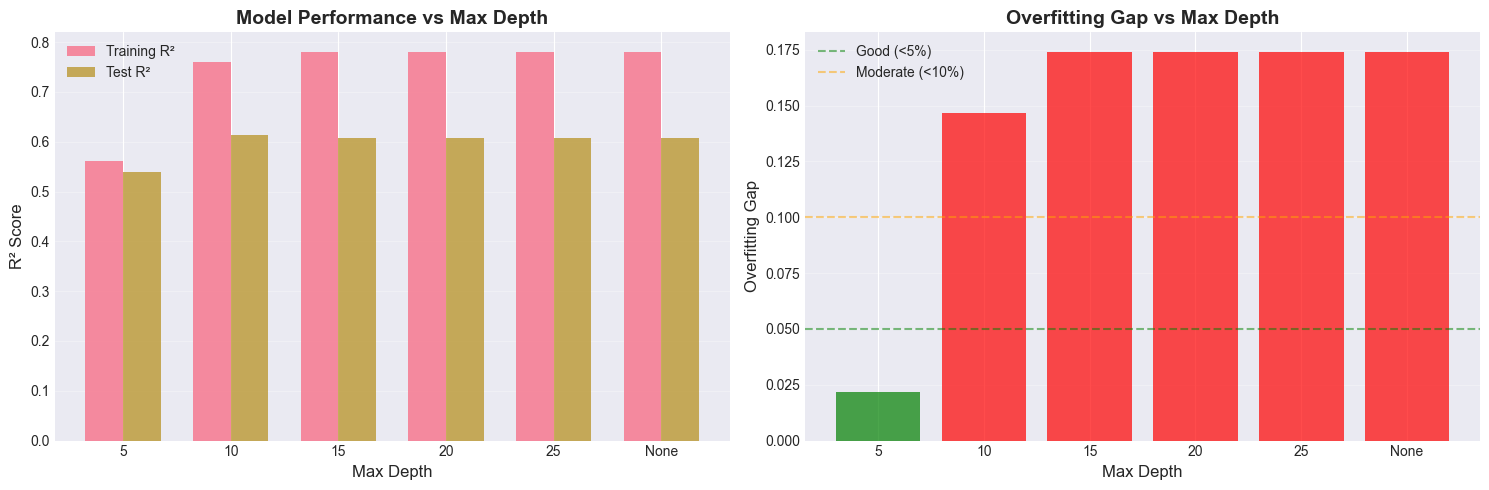


📊 Analysis: max_depth=15 balances complexity and generalization
   - Prevents overfitting while maintaining good test performance
   - Deeper trees (>15) increase overfitting without significant test score improvement


In [41]:
# Visualize max_depth impact
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x_pos = np.arange(len(results_depth_df))

# Plot 1: R² scores
width = 0.35
axes[0].bar(x_pos - width/2, results_depth_df['train_r2'], width, 
            label='Training R²', alpha=0.8)
axes[0].bar(x_pos + width/2, results_depth_df['test_r2'], width, 
            label='Test R²', alpha=0.8)
axes[0].set_xlabel('Max Depth', fontsize=12)
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('Model Performance vs Max Depth', fontsize=14, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(results_depth_df['max_depth'])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Overfitting gap
colors = ['green' if gap < 0.05 else 'orange' if gap < 0.1 else 'red' 
          for gap in results_depth_df['gap']]
axes[1].bar(x_pos, results_depth_df['gap'], color=colors, alpha=0.7)
axes[1].axhline(y=0.05, color='green', linestyle='--', alpha=0.5, label='Good (<5%)')
axes[1].axhline(y=0.10, color='orange', linestyle='--', alpha=0.5, label='Moderate (<10%)')
axes[1].set_xlabel('Max Depth', fontsize=12)
axes[1].set_ylabel('Overfitting Gap', fontsize=12)
axes[1].set_title('Overfitting Gap vs Max Depth', fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(results_depth_df['max_depth'])
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n📊 Analysis: max_depth=15 balances complexity and generalization")
print(f"   - Prevents overfitting while maintaining good test performance")
print(f"   - Deeper trees (>15) increase overfitting without significant test score improvement")

In [42]:
# Test different min_samples_split values
print("\nTesting different min_samples_split values...")
print("=" * 60)

min_samples_range = [2, 5, 10, 15, 20]
results_samples = []

for min_samples in min_samples_range:
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=min_samples,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    
    train_score = rf.score(X_train, y_train)
    test_score = rf.score(X_test, y_test)
    
    results_samples.append({
        'min_samples_split': min_samples,
        'train_r2': train_score,
        'test_r2': test_score,
        'gap': train_score - test_score
    })
    
    print(f"Min Samples: {min_samples:2d} | Train R²: {train_score:.4f} | Test R²: {test_score:.4f} | Gap: {train_score-test_score:.4f}")

results_samples_df = pd.DataFrame(results_samples)
print("\n✓ Min samples split analysis complete")


Testing different min_samples_split values...
Min Samples:  2 | Train R²: 0.7819 | Test R²: 0.6082 | Gap: 0.1737
Min Samples:  5 | Train R²: 0.7806 | Test R²: 0.6065 | Gap: 0.1741
Min Samples: 10 | Train R²: 0.7765 | Test R²: 0.6110 | Gap: 0.1655
Min Samples: 15 | Train R²: 0.7654 | Test R²: 0.6185 | Gap: 0.1469
Min Samples: 20 | Train R²: 0.7558 | Test R²: 0.6319 | Gap: 0.1239

✓ Min samples split analysis complete
